# Descrição
Esta competição é o enunciado final do Recognizance'24, o evento de Aprendizado de Máquina (ML) de Prastuti, o festival do Departamento de Eletricidade do IIT BHU.
É importante que as empresas de cartão de crédito sejam capazes de reconhecer transações fraudulentas com cartão de crédito para que os clientes não sejam cobrados por itens que não compraram.
Formule um modelo de ML para detectar transações fraudulentas com cartão de crédito.

# Descrição do Conjunto de Dados
Nesta competição, você prevê a probabilidade de uma transação online ser fraudulenta, conforme indicado pelo alvo binário isFraud.

Arquivos
train.csv - o conjunto de treinamento
test.csv - o conjunto de teste
sample_submission.csv - um arquivo de exemplo de envio no formato correto

# Avaliação
As submissões são avaliadas com base na área sob a curva ROC entre a probabilidade prevista e o alvo observado.

Arquivo de Submissão
Para cada ID no conjunto de teste, você deve prever uma probabilidade para a variável isFraud

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

In [2]:
pd.set_option('display.float_format', '{:,.2f}'.format) 
pd.set_option('display.max_columns', None)              
pd.set_option('display.width', None) 

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  150000 non-null  int64  
 1   Time                150000 non-null  float64
 2   feat1               150000 non-null  float64
 3   feat2               150000 non-null  float64
 4   feat3               150000 non-null  float64
 5   feat4               150000 non-null  float64
 6   feat5               150000 non-null  float64
 7   feat6               150000 non-null  float64
 8   feat7               150000 non-null  float64
 9   feat8               150000 non-null  float64
 10  feat9               150000 non-null  float64
 11  feat10              150000 non-null  float64
 12  feat11              150000 non-null  float64
 13  feat12              150000 non-null  float64
 14  feat13              150000 non-null  float64
 15  feat14              150000 non-nul

In [5]:
df_train.isnull().sum().sort_values(ascending=False)

id                    0
Time                  0
feat1                 0
feat2                 0
feat3                 0
feat4                 0
feat5                 0
feat6                 0
feat7                 0
feat8                 0
feat9                 0
feat10                0
feat11                0
feat12                0
feat13                0
feat14                0
feat15                0
feat16                0
feat17                0
feat18                0
feat19                0
feat20                0
feat21                0
feat22                0
feat23                0
feat24                0
feat25                0
feat26                0
feat27                0
feat28                0
Transaction_Amount    0
IsFraud               0
dtype: int64

In [6]:
df_train.head()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.00,2.07,-0.13,-1.14,0.41,-0.19,-1.21,0.11,-0.26,0.74,0.11,-1.07,-0.23,-1.10,0.50,0.17,0.07,-0.31,-0.32,0.10,-0.29,-0.33,-0.89,0.34,-0.11,-0.29,0.21,-0.08,-0.06,1.98,0
1,1,0.00,2.00,-1.25,-0.52,-0.89,-1.12,-0.27,-1.03,0.05,-0.11,0.91,0.84,-0.06,-0.12,-0.14,-0.04,1.65,-0.25,-0.81,0.72,0.07,0.05,-0.04,0.13,-0.46,-0.47,-0.46,-0.01,-0.04,84.00,0
2,2,0.00,0.09,1.00,-0.22,-0.44,0.67,-0.99,0.95,-0.08,-0.04,-0.82,-0.38,-0.23,-0.55,-0.89,-0.18,0.23,0.59,-0.32,-0.43,-0.02,-0.33,-0.80,0.15,0.95,-0.51,0.09,0.22,0.09,2.69,0
3,3,0.00,1.98,-0.18,-1.06,0.12,-0.22,-0.65,-0.09,-0.04,0.89,-0.01,0.64,0.68,-1.50,0.55,-0.82,-0.53,-0.10,-0.31,0.64,-0.34,-0.10,-0.08,0.17,-0.04,0.00,-0.10,-0.06,-0.07,1.00,0
4,4,0.00,1.03,-0.17,1.20,1.24,-0.64,1.10,-0.94,0.57,0.69,-0.10,1.34,1.39,-0.13,-0.08,0.10,-0.34,0.09,-0.42,-0.73,-0.20,0.10,0.61,0.03,-0.26,0.26,-0.25,0.11,0.02,1.00,0


In [7]:
df_train.duplicated().sum()

np.int64(0)

In [8]:
df_train.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,"150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00"
mean,"74,999.50","49,785.42",0.07,-0.00,0.74,0.10,-0.25,0.15,-0.17,0.17,-0.13,-0.02,0.17,-0.00,-0.06,0.03,0.16,0.02,0.04,-0.08,-0.01,0.02,-0.03,-0.07,-0.06,-0.00,0.16,0.02,0.01,0.02,71.07,0.00
std,"43,301.41","18,733.66",1.35,1.16,1.01,1.23,1.05,1.18,0.80,0.69,1.00,0.79,0.98,0.93,1.01,0.75,0.88,0.79,0.68,0.79,0.74,0.44,0.40,0.57,0.32,0.58,0.39,0.47,0.22,0.16,158.71,0.04
min,0.00,0.00,-22.17,-44.25,-19.09,-5.07,-21.09,-25.66,-31.18,-28.90,-8.76,-16.04,-4.19,-16.18,-4.20,-15.59,-4.16,-11.78,-20.76,-7.46,-4.08,-13.84,-14.69,-7.35,-11.96,-2.83,-3.96,-1.41,-9.23,-4.45,0.00,0.00
25%,"37,499.75","39,411.00",-0.84,-0.62,0.18,-0.74,-0.91,-0.59,-0.67,-0.08,-0.74,-0.46,-0.57,-0.41,-0.73,-0.33,-0.38,-0.46,-0.39,-0.55,-0.47,-0.16,-0.19,-0.46,-0.18,-0.32,-0.08,-0.31,-0.04,0.00,6.99,0.00
50%,"74,999.50","53,785.00",0.67,0.00,0.83,0.10,-0.32,-0.07,-0.14,0.13,-0.17,-0.09,0.10,0.10,-0.06,0.02,0.25,0.06,-0.01,-0.07,-0.00,-0.03,-0.04,-0.05,-0.07,0.04,0.18,-0.09,0.02,0.02,24.90,0.00
75%,"112,499.25","63,833.00",1.17,0.75,1.36,0.97,0.24,0.49,0.33,0.40,0.47,0.45,0.94,0.62,0.59,0.40,0.83,0.54,0.42,0.39,0.47,0.14,0.10,0.31,0.05,0.39,0.43,0.27,0.07,0.07,74.00,0.00
max,"149,999.00","73,899.00",2.39,16.07,6.15,12.55,34.58,15.08,23.26,18.27,8.08,15.87,9.42,5.31,5.98,6.08,4.69,4.20,8.85,4.85,4.09,15.41,22.06,6.16,12.73,4.57,3.11,3.12,6.46,23.26,"6,513.35",1.00


In [9]:
df_train["IsFraud"].value_counts()

IsFraud
0    149731
1       269
Name: count, dtype: int64

In [10]:
df_IsFraud = df_train[df_train["IsFraud"] == 1]
df_IsFraud.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00
mean,"72,309.19","47,920.66",-1.03,-0.00,-0.46,0.79,-0.06,0.16,-0.53,-0.24,0.12,-0.49,0.58,-0.31,-0.04,-0.57,0.31,-0.12,0.20,0.24,-0.18,0.17,0.03,-0.11,-0.20,-0.02,0.17,-0.15,-0.00,0.13,143.60,1.00
std,"45,051.52","20,362.00",3.02,4.30,2.77,1.72,2.17,1.74,2.70,2.27,1.49,1.93,1.31,1.81,1.08,2.19,0.99,1.59,2.42,1.19,0.90,1.65,1.09,0.75,1.19,0.63,0.61,0.44,0.74,1.47,463.10,0.00
min,"1,681.00",764.00,-19.35,-44.25,-19.09,-3.51,-16.14,-5.79,-21.88,-17.37,-8.76,-11.08,-2.85,-12.81,-2.79,-13.71,-2.75,-10.78,-18.11,-7.46,-2.85,-12.75,-5.17,-5.11,-8.90,-1.75,-3.96,-1.02,-9.23,-2.24,0.00,1.00
25%,"31,783.00","37,485.00",-1.72,-0.24,-1.16,-0.07,-0.81,-0.80,-0.85,-0.27,-0.63,-1.10,-0.33,-0.73,-0.75,-0.96,-0.15,-0.59,-0.41,-0.21,-0.82,-0.20,-0.23,-0.50,-0.22,-0.37,-0.13,-0.40,-0.04,-0.01,1.00,1.00
50%,"70,315.00","52,667.00",-0.55,0.49,0.09,0.88,-0.07,-0.09,-0.27,0.05,-0.01,-0.36,0.54,0.14,-0.07,-0.09,0.46,0.12,0.15,0.29,-0.23,-0.04,-0.05,-0.06,-0.06,-0.02,0.17,-0.27,0.04,0.03,10.00,1.00
75%,"110,905.00","63,522.00",1.12,1.32,1.06,1.37,0.78,0.71,0.35,0.47,0.87,0.08,1.28,0.65,0.68,0.57,1.00,0.69,0.95,0.96,0.36,0.18,0.18,0.32,0.10,0.40,0.53,0.08,0.11,0.12,59.95,1.00
max,"149,812.00","73,885.00",1.99,8.44,3.35,8.83,8.84,7.36,15.92,14.07,5.72,10.78,6.30,2.64,3.36,3.92,2.80,4.20,5.50,2.76,2.79,13.59,6.37,2.55,5.31,1.08,2.42,1.15,1.94,23.26,"4,471.96",1.00


In [11]:
df_IsNotFraud = df_train[df_train["IsFraud"] == 0]
df_IsNotFraud.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,"149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00","149,731.00"
mean,"75,004.33","49,788.77",0.07,-0.00,0.74,0.10,-0.25,0.15,-0.16,0.17,-0.13,-0.01,0.17,-0.00,-0.06,0.03,0.16,0.02,0.04,-0.08,-0.01,0.02,-0.03,-0.07,-0.06,-0.00,0.16,0.02,0.01,0.02,70.93,0.00
std,"43,298.21","18,730.51",1.34,1.15,1.01,1.23,1.05,1.18,0.80,0.68,1.00,0.79,0.98,0.93,1.01,0.74,0.88,0.79,0.68,0.79,0.74,0.44,0.40,0.57,0.32,0.58,0.38,0.47,0.22,0.15,157.61,0.00
min,0.00,0.00,-22.17,-32.17,-18.40,-5.07,-21.09,-25.66,-31.18,-28.90,-7.01,-16.04,-4.19,-16.18,-4.20,-15.59,-4.16,-11.78,-20.76,-7.25,-4.08,-13.84,-14.69,-7.35,-11.96,-2.83,-2.72,-1.41,-8.25,-4.45,0.00,0.00
25%,"37,506.50","39,412.00",-0.84,-0.62,0.18,-0.74,-0.91,-0.59,-0.67,-0.08,-0.74,-0.46,-0.57,-0.41,-0.73,-0.33,-0.38,-0.46,-0.39,-0.55,-0.47,-0.16,-0.19,-0.46,-0.18,-0.32,-0.08,-0.31,-0.04,0.00,6.99,0.00
50%,"75,009.00","53,786.00",0.67,0.00,0.83,0.09,-0.32,-0.07,-0.14,0.13,-0.17,-0.09,0.10,0.10,-0.06,0.02,0.25,0.06,-0.01,-0.07,-0.00,-0.02,-0.04,-0.05,-0.07,0.04,0.18,-0.09,0.02,0.02,24.90,0.00
75%,"112,500.50","63,833.00",1.17,0.75,1.36,0.97,0.24,0.49,0.33,0.40,0.47,0.45,0.94,0.62,0.59,0.40,0.83,0.54,0.42,0.39,0.47,0.14,0.10,0.31,0.05,0.39,0.43,0.27,0.07,0.07,74.00,0.00
max,"149,999.00","73,899.00",2.39,16.07,6.15,12.55,34.58,15.08,23.26,18.27,8.08,15.87,9.42,5.31,5.98,6.08,4.69,4.18,8.85,4.85,4.09,15.41,22.06,6.16,12.73,4.57,3.11,3.12,6.46,6.50,"6,513.35",0.00


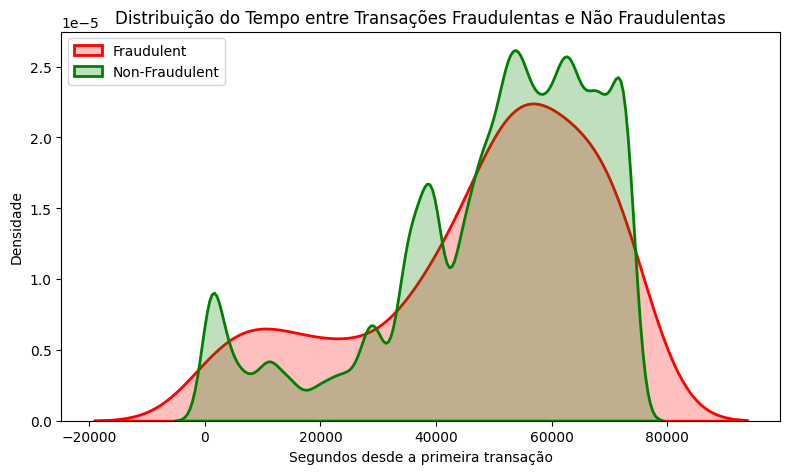

In [12]:
plt.figure(figsize=(8, 5))

# Curvas de densidade
sns.kdeplot(df_IsFraud['Time'], label='Fraudulent', fill=True, color='red', linewidth=2)
sns.kdeplot(df_IsNotFraud['Time'], label='Non-Fraudulent', fill=True, color='green', linewidth=2)

# Rótulos e título
plt.xlabel('Segundos desde a primeira transação')
plt.ylabel('Densidade')
plt.title('Distribuição do Tempo entre Transações Fraudulentas e Não Fraudulentas')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
cols = df_train.columns
cols = cols.drop(['IsFraud', 'id','Time'])
cols

Index(['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8',
       'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15',
       'feat16', 'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22',
       'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28',
       'Transaction_Amount'],
      dtype='object')

In [14]:
pt = PowerTransformer(method='yeo-johnson', standardize=True, copy=False)
# Fit and transform the PT on training data
df_train[cols] = pt.fit_transform(df_train[cols])
df_IsFraud[cols] = pt.transform(df_IsFraud[cols])

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17328\2638313382.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IsFraud[cols] = pt.transform(df_IsFraud[cols])


In [15]:
df_train.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,"150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00","150,000.00"
mean,"74,999.50","49,785.42",0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00
std,"43,301.41","18,733.66",1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.04
min,0.00,0.00,-5.48,-22.00,-8.60,-4.33,-29.02,-69.58,-33.71,-23.44,-10.86,-30.96,-4.69,-7.12,-4.21,-14.99,-3.64,-10.41,-30.57,-8.84,-5.21,-45.53,-47.11,-10.58,-42.15,-3.90,-6.89,-5.33,-26.00,-31.96,-2.01,0.00
25%,"37,499.75","39,411.00",-0.88,-0.60,-0.67,-0.68,-0.61,-0.62,-0.63,-0.43,-0.59,-0.54,-0.75,-0.60,-0.66,-0.52,-0.69,-0.65,-0.64,-0.60,-0.64,-0.39,-0.37,-0.70,-0.36,-0.60,-0.68,-0.68,-0.30,-0.11,-0.69,0.00
50%,"74,999.50","53,785.00",0.32,-0.07,-0.01,0.00,-0.01,-0.06,0.01,-0.12,0.01,-0.04,-0.05,-0.05,0.01,-0.06,-0.00,-0.01,-0.07,-0.00,-0.01,-0.08,-0.02,0.01,-0.02,0.01,-0.02,-0.07,-0.01,0.03,0.06,0.00
75%,"112,499.25","63,833.00",0.92,0.65,0.60,0.71,0.53,0.44,0.62,0.32,0.63,0.63,0.79,0.66,0.65,0.47,0.75,0.64,0.55,0.58,0.63,0.29,0.35,0.65,0.34,0.64,0.67,0.69,0.25,0.29,0.74,0.00
max,"149,999.00","73,899.00",2.72,21.94,8.04,9.66,21.18,6.72,33.53,49.35,6.63,13.90,8.67,11.54,5.80,10.20,7.43,6.61,12.81,6.53,5.85,25.13,41.69,13.08,34.57,11.14,11.09,3.41,46.20,107.58,3.62,1.00


In [16]:
def plot_feature_distribution(data, column, title=None, subplot=False, c=None, color='skyblue'):

    ax = plt.gca() if subplot else None
    sns.histplot(data[column], kde=True, ax=ax, color=color)
    
    if subplot:
        ax.set_title(title)
        ax.set_xlabel(column)
        ax.set_ylabel("Frequência")

    if not subplot:
        plt.tight_layout()
        plt.show()

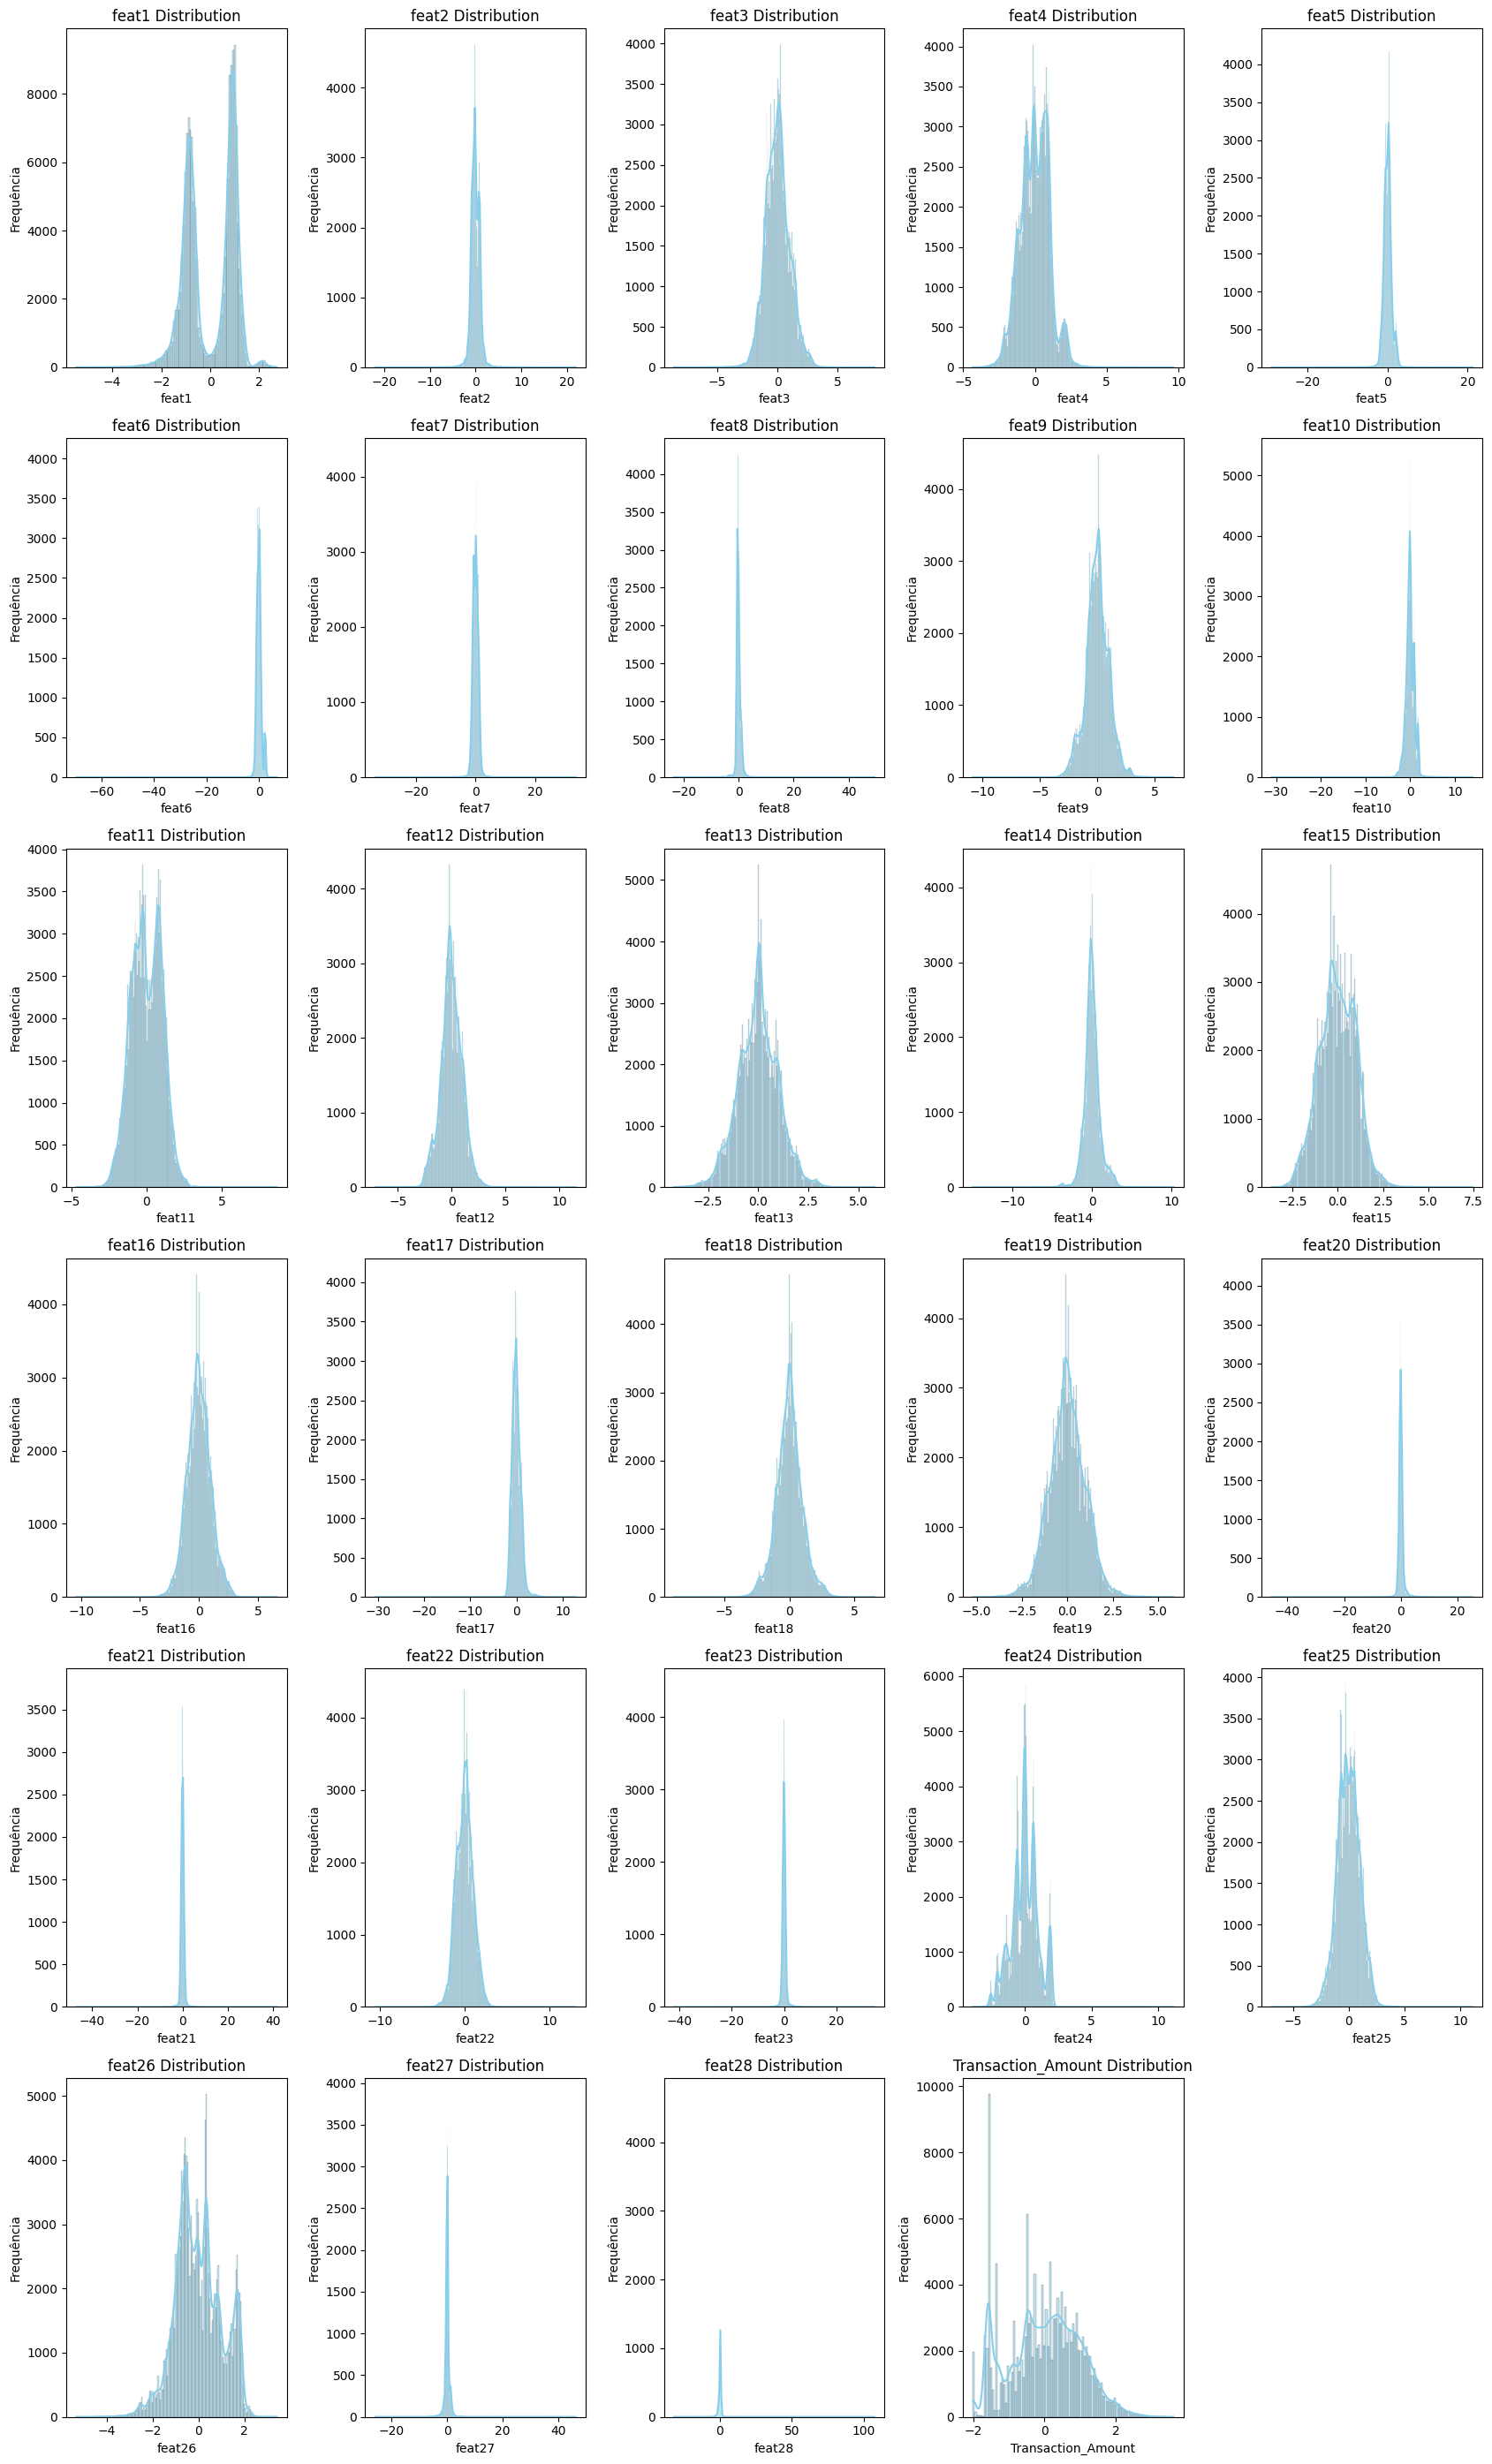

In [17]:
c = 0
plt.figure(figsize=(17, 28))

for col in cols:
    c += 1
    plt.subplot(6, 5, c)
    plot_feature_distribution(df_train, col, title=f"{col} Distribution", subplot=True, c=c)

plt.tight_layout()
plt.show()

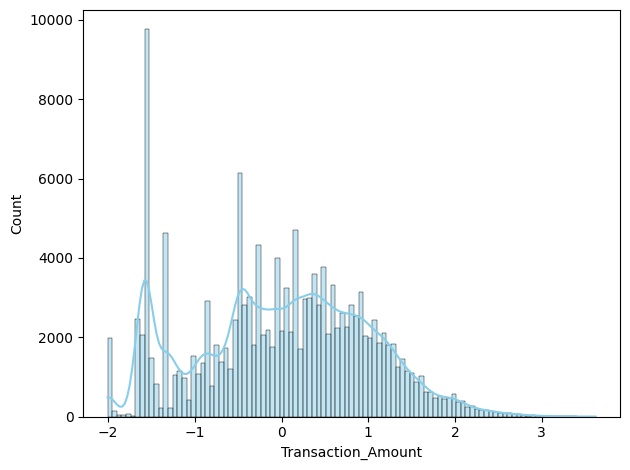

In [18]:
plot_feature_distribution(df_train, column='Transaction_Amount', title='Transaction Amount Distribution')

In [19]:
df_IsFraud.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,feat13,feat14,feat15,feat16,feat17,feat18,feat19,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00,269.00
mean,"72,309.19","47,920.66",-0.51,0.31,-0.82,0.55,0.07,-0.16,-0.39,-0.28,0.21,-0.80,0.40,-0.14,0.02,-0.60,0.20,-0.08,0.22,0.42,-0.23,0.16,0.07,-0.05,-0.51,-0.02,0.10,-0.41,0.08,0.50,-0.26,1.00
std,"45,051.52","20,362.00",1.34,2.81,1.75,1.38,2.31,1.66,3.29,3.43,1.51,2.82,1.30,1.45,1.07,2.52,1.15,1.73,3.54,1.49,1.22,3.96,2.73,1.27,3.99,1.08,1.55,1.06,2.68,6.98,1.29,0.00
min,"1,681.00",764.00,-5.11,-22.00,-8.60,-3.00,-21.28,-9.49,-24.01,-15.86,-10.86,-20.11,-3.21,-6.20,-2.75,-13.44,-2.67,-9.67,-26.67,-8.84,-3.69,-41.44,-14.94,-7.58,-30.76,-2.60,-6.89,-3.34,-26.00,-15.40,-2.01,1.00
25%,"31,783.00","37,485.00",-1.32,-0.28,-1.71,-0.13,-0.51,-0.88,-0.85,-0.71,-0.48,-1.46,-0.50,-0.88,-0.68,-1.30,-0.46,-0.80,-0.66,-0.18,-1.10,-0.50,-0.48,-0.76,-0.49,-0.68,-0.79,-0.95,-0.27,-0.16,-1.57,1.00
50%,"70,315.00","52,667.00",-0.71,0.39,-0.76,0.64,0.24,-0.08,-0.15,-0.23,0.17,-0.41,0.39,0.00,-0.00,-0.20,0.27,0.07,0.16,0.45,-0.32,-0.12,-0.03,-0.01,0.01,-0.11,-0.05,-0.55,0.08,0.07,-0.48,1.00
75%,"110,905.00","63,522.00",0.85,1.23,0.25,1.03,1.00,0.61,0.63,0.45,1.00,0.17,1.12,0.70,0.74,0.72,0.99,0.83,1.32,1.33,0.48,0.39,0.55,0.66,0.49,0.66,0.99,0.31,0.41,0.63,0.61,1.00
max,"149,812.00","73,885.00",2.07,10.31,3.33,6.82,6.74,4.06,22.61,35.77,4.91,10.04,5.85,4.47,3.33,6.22,3.86,6.61,7.94,3.71,3.94,22.56,13.64,5.08,15.23,2.06,7.99,1.91,10.91,107.58,3.38,1.00


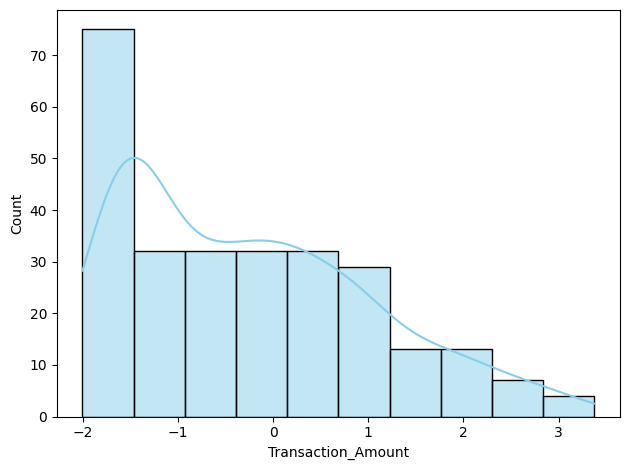

In [20]:
plot_feature_distribution(df_IsFraud, 'Transaction_Amount', 'Transaction Amount Distribution for Fraudulent Transactions')

In [21]:
def plot_correlation_matrix(df, title='Correlation Matrix'):
    plt.figure(figsize=(18, 14))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title(title)
    plt.show()

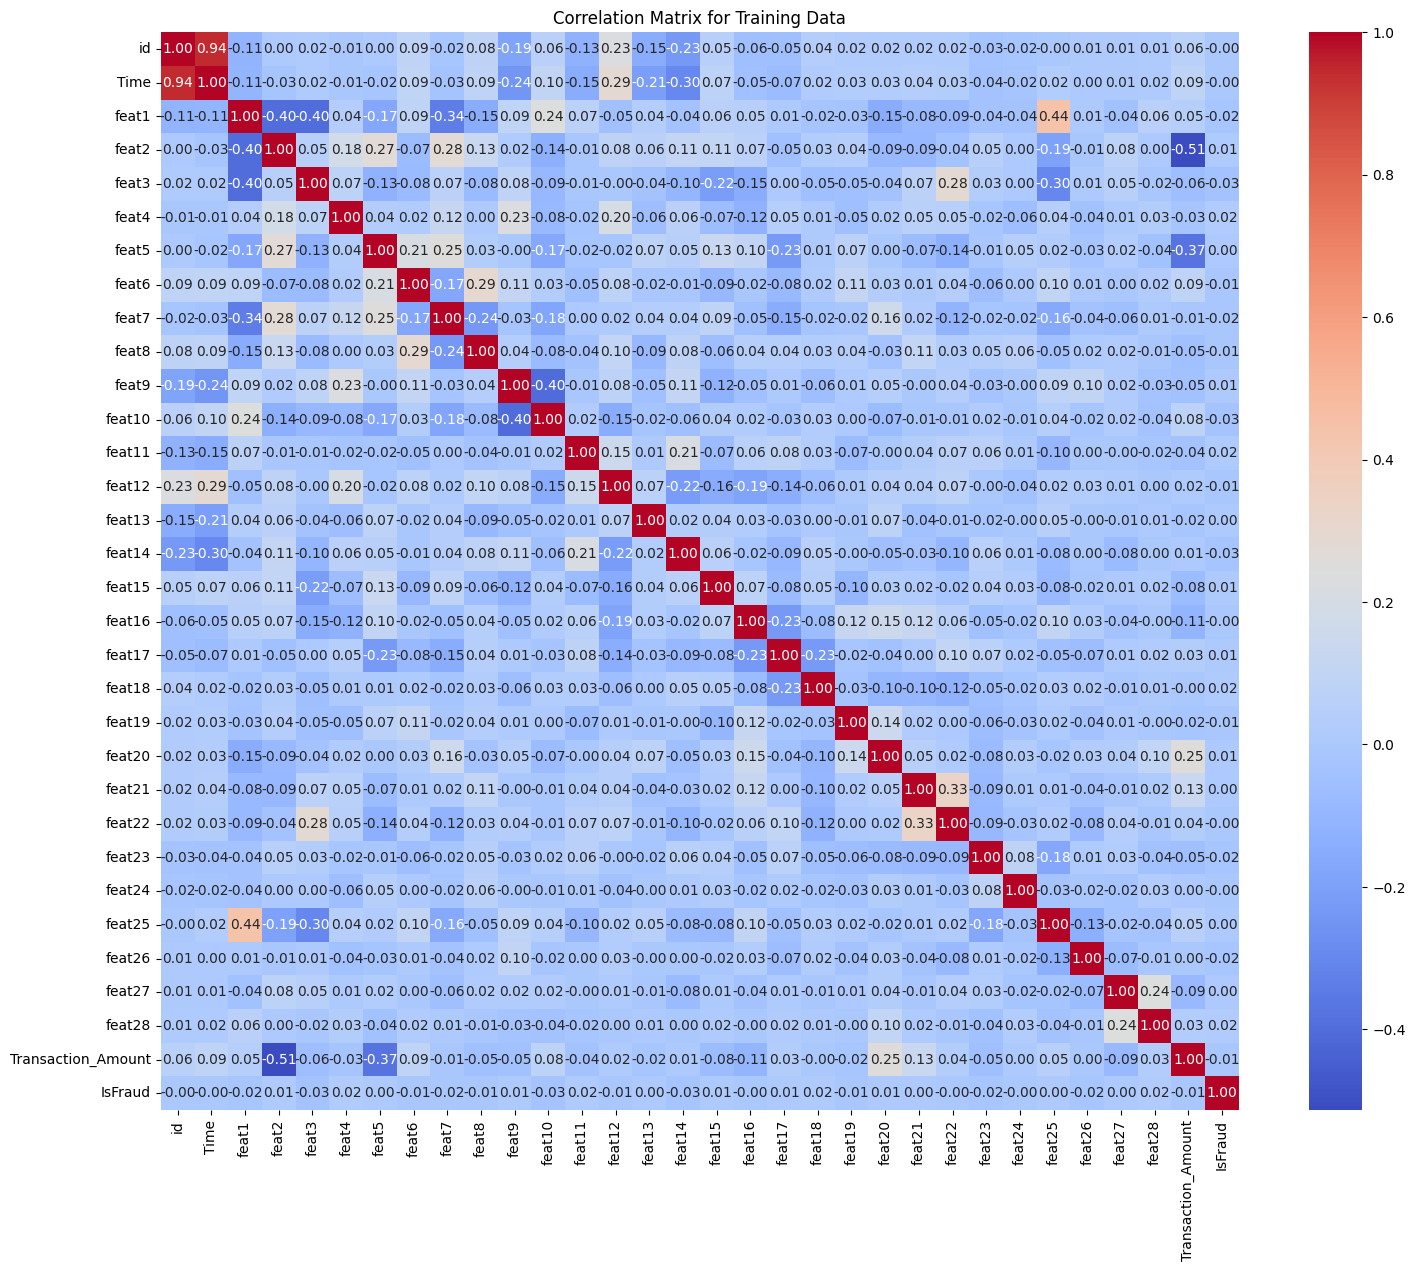

In [22]:
plot_correlation_matrix(df_train, title='Correlation Matrix for Training Data')

MODELANDO